# **Data Mining Project - Shayan - 40266331003**

# Data & Packages

In [14]:
# !pip install numpy pandas seaborn matplotlib scikit-learn

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans                       # Kmeans for clustering
from sklearn.cluster import DBSCAN                       # DBSCAN for clustering
from sklearn.decomposition import PCA                    # PCA    for Dimension Reduction
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [16]:
path = r"C:\Users\User\Desktop\Customer Clustering\Customer_Data .csv"

In [17]:
data = pd.read_csv(path, encoding='unicode_escape')
data

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

As part of the preprocessing phase, the CUST_ID column was removed because it only represents customer identifiers and does not provide useful information for clustering. Furthermore, missing data were found in the CREDIT_LIMIT and MINIMUM_PAYMENTS features, which were addressed before training the clustering models.

In [19]:
# Remove rows with missing values
cleaned_data = data.dropna()
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 8636 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8636 non-null   str    
 1   BALANCE                           8636 non-null   float64
 2   BALANCE_FREQUENCY                 8636 non-null   float64
 3   PURCHASES                         8636 non-null   float64
 4   ONEOFF_PURCHASES                  8636 non-null   float64
 5   INSTALLMENTS_PURCHASES            8636 non-null   float64
 6   CASH_ADVANCE                      8636 non-null   float64
 7   PURCHASES_FREQUENCY               8636 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8636 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8636 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8636 non-null   float64
 11  CASH_ADVANCE_TRX                  8636 non-null   int64  
 12  PURCHASES_TRX         

In [20]:
cleaned_data_numeric = cleaned_data.drop(columns=['CUST_ID'])

---

# PreProcessing

### BALANCE Distribution

Text(0.5, 1.0, 'Distribution of BALANCE')

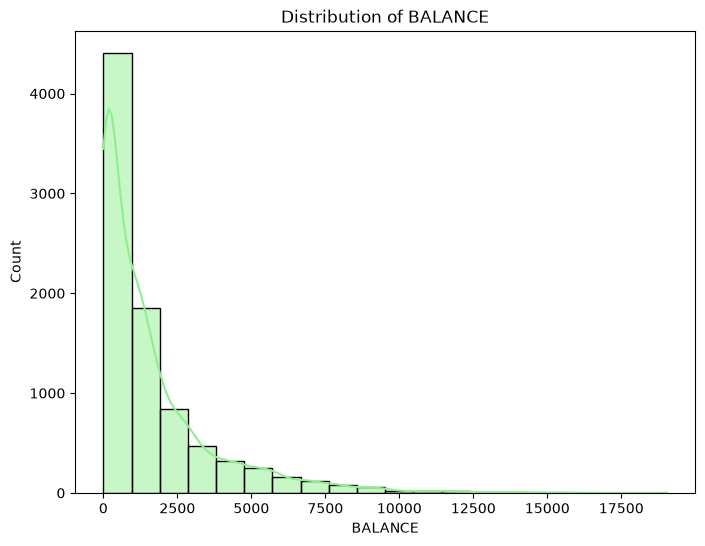

In [56]:
plt.figure(figsize=(8, 6))
sns.histplot(cleaned_data_numeric['BALANCE'], bins=20, kde=True, color='lightgreen')
plt.title('Distribution of BALANCE')

### PURCHASES Distribution 

Text(0.5, 1.0, 'Distribution of PURCHASES')

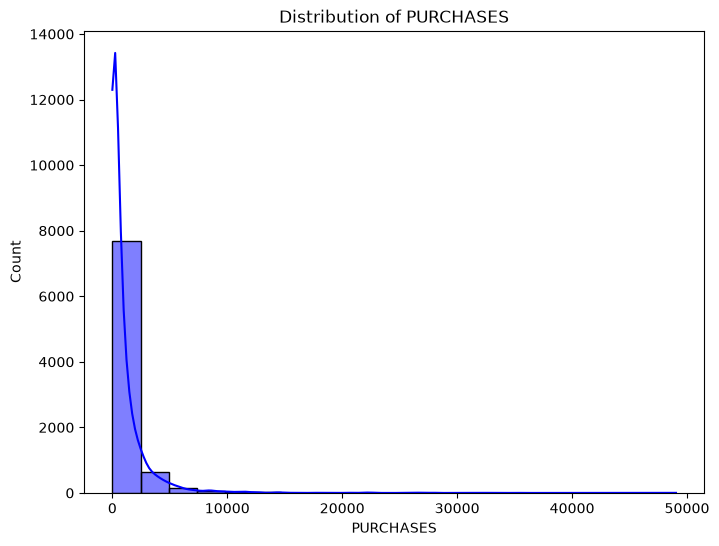

In [60]:
plt.figure(figsize=(8, 6))
sns.histplot(cleaned_data_numeric['PURCHASES'], bins=20, kde=True, color='blue')
plt.title('Distribution of PURCHASES')

### CREDIT_LIMIT Distribution

Text(0.5, 1.0, 'Boxplot of CREDIT_LIMIT')

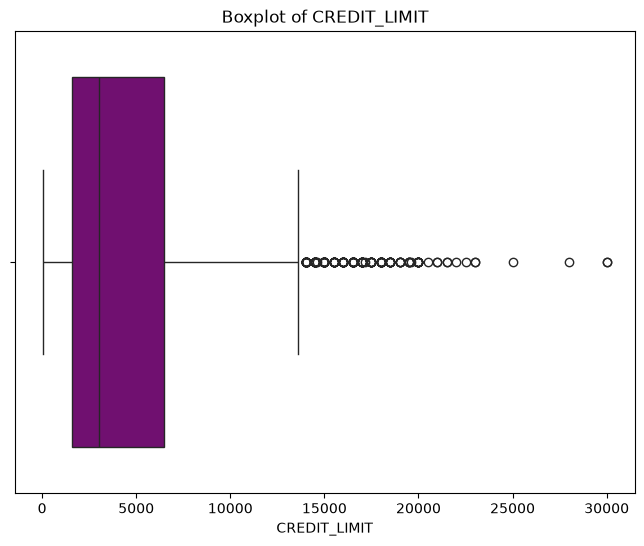

In [61]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=cleaned_data_numeric['CREDIT_LIMIT'], color='purple')
plt.title('Boxplot of CREDIT_LIMIT')

### ONEOFF_PURCHASES vs. INSTALLMENTS_PURCHASES / Scatter Plot

Text(0.5, 1.0, 'ONEOFF_PURCHASES vs. INSTALLMENTS_PURCHASES')

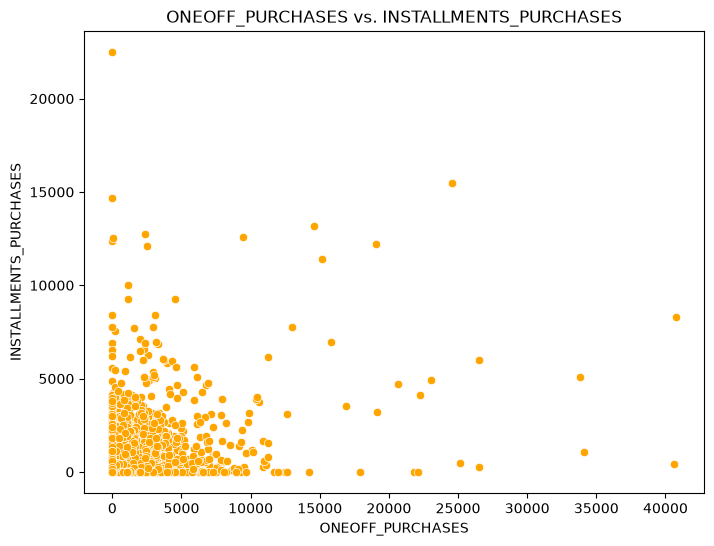

In [62]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ONEOFF_PURCHASES', y='INSTALLMENTS_PURCHASES', data=cleaned_data_numeric, color='orange')
plt.title('ONEOFF_PURCHASES vs. INSTALLMENTS_PURCHASES')

### Correlation Heatmap

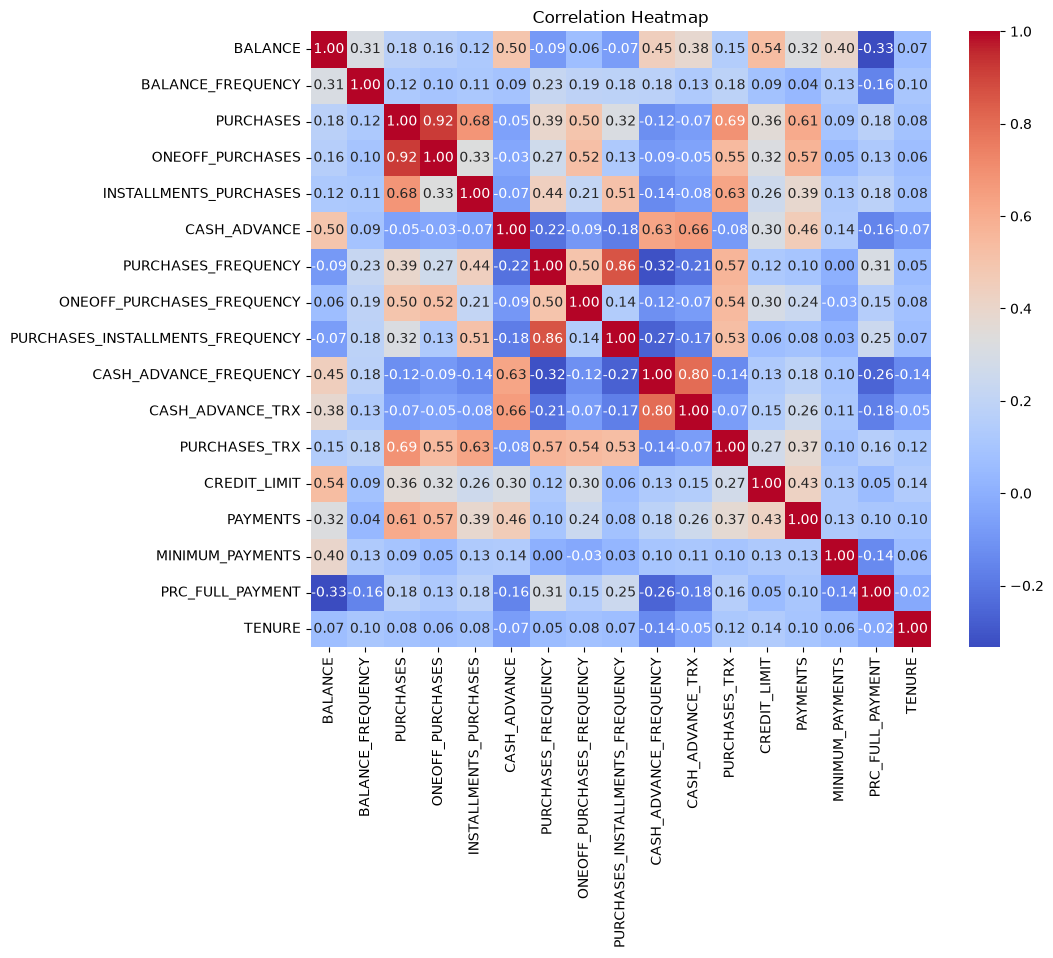

In [64]:
plt.figure(figsize=(10, 8))

correlation_matrix = cleaned_data_numeric.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,          
    fmt=".2f",          
    cmap='coolwarm',
    cbar=True
)

plt.title('Correlation Heatmap')
plt.show()

### TENURE Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_17304\1799200777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='TENURE', data=cleaned_data_numeric, palette='Set2')


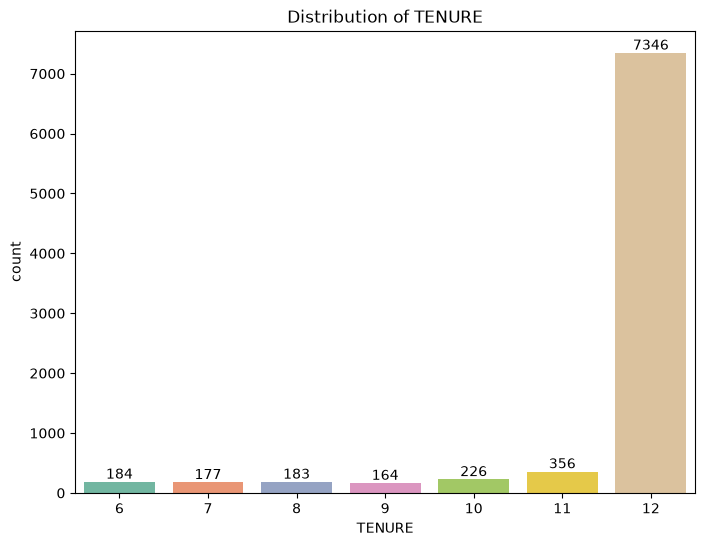

In [68]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(x='TENURE', data=cleaned_data_numeric, palette='Set2')

plt.title('Distribution of TENURE')

# Numbers on columns
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.show()

### Relationship between PURCHASES and PAYMENTS

Text(0.5, 1.0, 'PURCHASES vs. PAYMENTS')

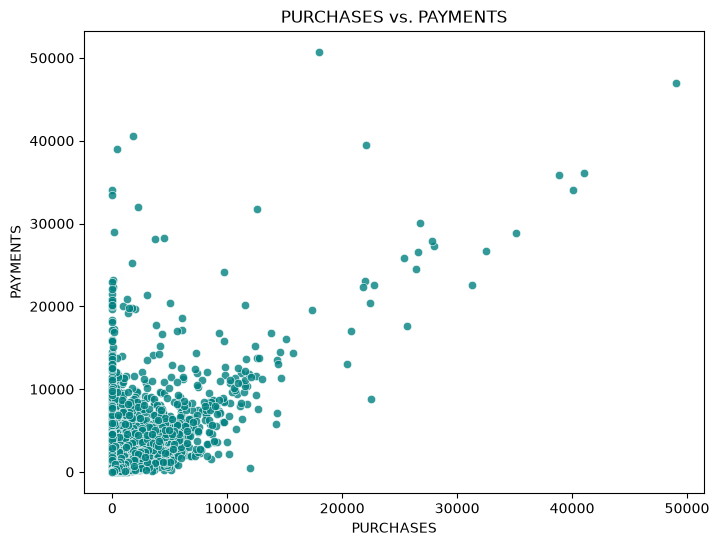

In [69]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PURCHASES', y='PAYMENTS', data=cleaned_data_numeric, alpha=0.8, color='teal')
plt.title('PURCHASES vs. PAYMENTS')

### PRC_FULL_PAYMENT Boxplot

Text(0.5, 1.0, 'Boxplot of PRC_FULL_PAYMENT')

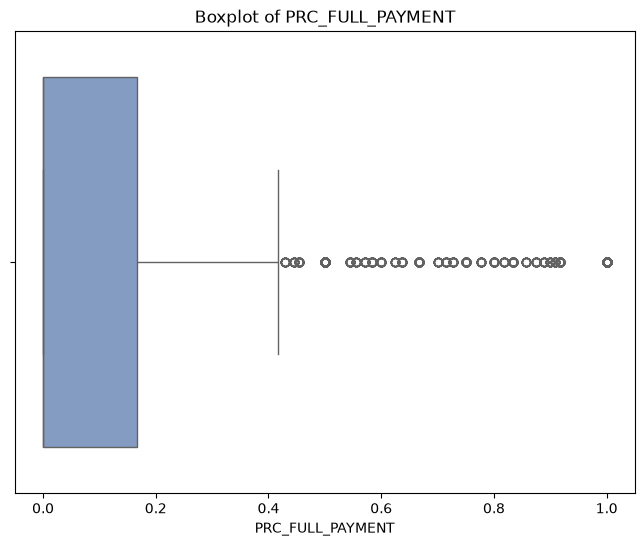

In [72]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=cleaned_data_numeric['PRC_FULL_PAYMENT'], color='#7b9acc')
plt.title('Boxplot of PRC_FULL_PAYMENT')

###  MINIMUM_PAYMENTS Distribution

Text(0.5, 1.0, 'Distribution of MINIMUM_PAYMENTS')

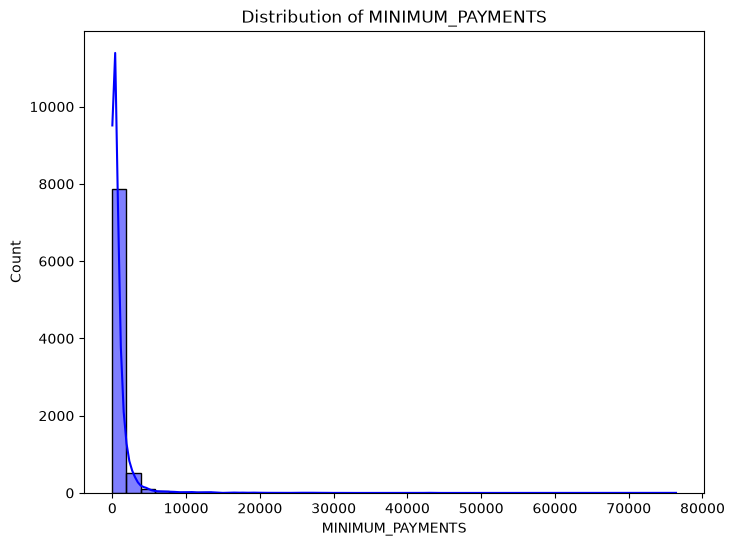

In [74]:
plt.figure(figsize=(8, 6))
sns.histplot(cleaned_data_numeric['MINIMUM_PAYMENTS'], bins=40, kde=True, color='blue')
plt.title('Distribution of MINIMUM_PAYMENTS')

###  CASH_ADVANCE_TRX Boxplot

Text(0.5, 1.0, 'CASH_ADVANCE_TRX Distribution')

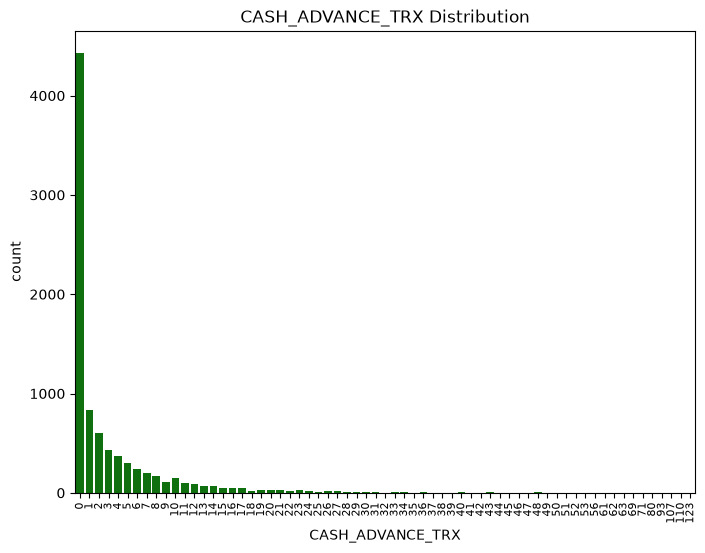

In [75]:
plt.figure(figsize=(8, 6))
sns.countplot(x='CASH_ADVANCE_TRX', data=cleaned_data_numeric, color='green')
plt.xticks(rotation=90, fontsize=8)
plt.title('CASH_ADVANCE_TRX Distribution')

### Pair Plot

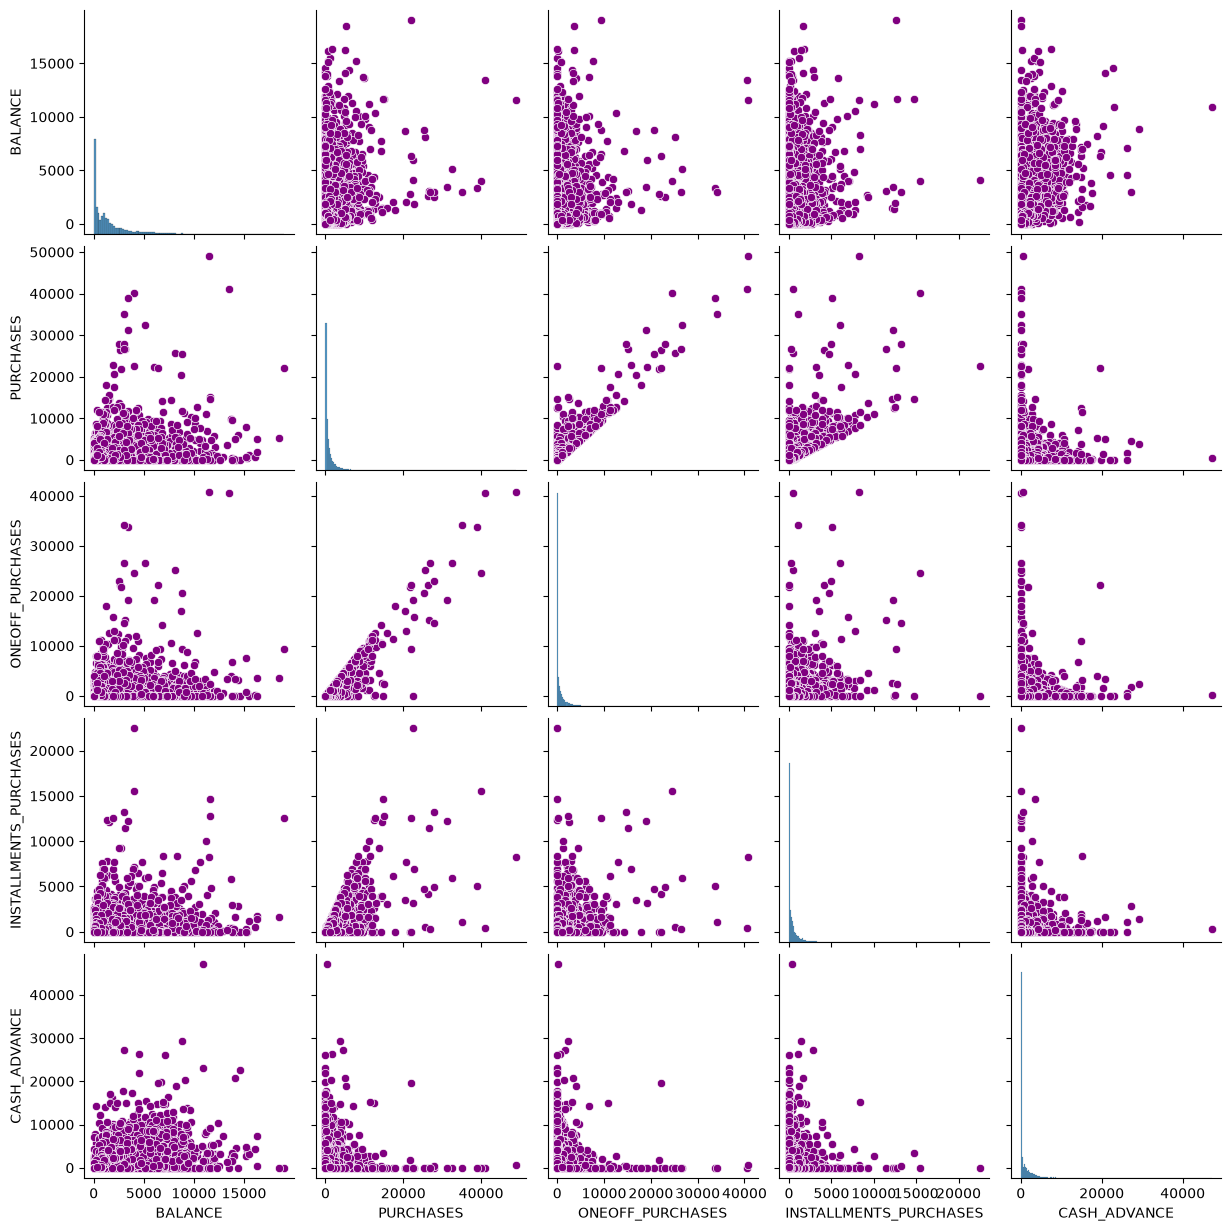

In [76]:
sns.pairplot(
    cleaned_data_numeric[['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE']],
    plot_kws={'color': 'purple'}
)

plt.show()

---

# Scaling

which scaler is more suitable for each algorithms, MinMaxScaler or StandardScaler?

#### Normalize data with MinMaxScaler

In [32]:
minmax_scaler = MinMaxScaler()
minmax_scaled_data = minmax_scaler.fit_transform(cleaned_data_numeric)

#### Normalize data with StandardScaler

In [33]:
standard_scaler = StandardScaler()
standard_scaled_data = standard_scaler.fit_transform(cleaned_data_numeric)

### Scaling K-Means

In [34]:
# K-Means Clustering on both scaled datasets
kmeans_minmax = KMeans(n_clusters=3, random_state=42, n_init=10).fit(minmax_scaled_data)
kmeans_standard = KMeans(n_clusters=3, random_state=42, n_init=10).fit(standard_scaled_data)

#### Using Silhouette Scores to find out about the better Scaling option for K-Means

In [35]:
silhouette_minmax = silhouette_score(minmax_scaled_data, kmeans_minmax.labels_)
silhouette_standard = silhouette_score(standard_scaled_data, kmeans_standard.labels_)

print(f"Silhouette Score (MinMaxScaler): {silhouette_minmax}")
print(f"Silhouette Score (StandardScaler): {silhouette_standard}")

Silhouette Score (MinMaxScaler): 0.3764256528455333
Silhouette Score (StandardScaler): 0.24709726016009056


So we found out that for K-Means algorithm MinMaxScaler is more accurate

### Scaling **DBSCAN**

In [36]:
# DBSCAN parameters, both parameters are editable
eps = 0.5
min_samples = 5

# DBSCAN with MinMaxScaler
dbscan_minmax = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_minmax_labels = dbscan_minmax.fit_predict(minmax_scaled_data)

# Check if clusters are formed
if len(set(dbscan_minmax_labels)) > 1:
    silhouette_minmax = silhouette_score(minmax_scaled_data, dbscan_minmax_labels)
else:
    silhouette_minmax = -1

In [37]:
# DBSCAN with StandardScaler
dbscan_standard = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_standard_labels = dbscan_standard.fit_predict(standard_scaled_data)

#### Using Silhouette Scores to find out about the better Scaling option for DBSCAN

In [38]:
# Check if clusters are formed
if len(set(dbscan_standard_labels)) > 1:
    silhouette_standard = silhouette_score(standard_scaled_data, dbscan_standard_labels)
else:
    silhouette_standard = -1

print(f"DBSCAN Silhouette Score (MinMaxScaler): {silhouette_minmax}")
print(f"DBSCAN Silhouette Score (StandardScaler): {silhouette_standard}")

DBSCAN Silhouette Score (MinMaxScaler): 0.3466468888469743
DBSCAN Silhouette Score (StandardScaler): -0.46511775211506606


The evaluation results indicate that MinMaxScaler provides a more appropriate normalization strategy for the DBSCAN model. In contrast, applying StandardScaler resulted in a negative Silhouette Score, suggesting that the clustering structure was not meaningful and that a considerable number of samples were either incorrectly grouped or classified as noise points.

### Scaling **Gaussian Mixture Model (GMM)**

In [39]:
# GMM parameter which is editable
n_components = 3

# GMM with MinMaxScaler
gmm_minmax = GaussianMixture(n_components=n_components, random_state=42)
gmm_minmax_labels = gmm_minmax.fit_predict(minmax_scaled_data)
silhouette_minmax = silhouette_score(minmax_scaled_data, gmm_minmax_labels)

In [40]:
# GMM with StandardScaler
gmm_standard = GaussianMixture(n_components=n_components, random_state=42)
gmm_standard_labels = gmm_standard.fit_predict(standard_scaled_data)
silhouette_standard = silhouette_score(standard_scaled_data, gmm_standard_labels)

#### Silhouette Scores to find out about the better Scaling option for GMM

In [41]:
print(f"GMM Silhouette Score (MinMaxScaler): {silhouette_minmax}")
print(f"GMM Silhouette Score (StandardScaler): {silhouette_standard}")

GMM Silhouette Score (MinMaxScaler): 0.1380020894078091
GMM Silhouette Score (StandardScaler): 0.11512267967773164


Similarly, in this algorithm also MinMaxScaler works better

---

# Clustering

### Clustering using **"K-Mean" algorithm**

In [42]:
# K-Means parameter which I choose randomly
n_clusters = 3

# Apply K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(minmax_scaled_data)

# Evaluate K-Means with Silhouette Score
kmeans_silhouette = silhouette_score(minmax_scaled_data, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_silhouette}")

K-Means Silhouette Score: 0.3764256528455333


### Clustering using **"DBSCAN" algorithm**

In [43]:
# DBSCAN parameters which I choose randomly
eps = 0.5
min_samples = 5

# Apply DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(minmax_scaled_data)

# Evaluate DBSCAN with Silhouette Score (only if valid clusters exist)
if len(set(dbscan_labels)) > 1:
    dbscan_silhouette = silhouette_score(minmax_scaled_data, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {dbscan_silhouette}")
else:
    print("DBSCAN failed to form meaningful clusters.")

DBSCAN Silhouette Score: 0.3466468888469743


### Clustering using ***"Gaussian Mixture Model" algorithm**

In [44]:
# GMM parameter which I choose randomly
n_components = 3

# Apply GMM
gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm_labels = gmm.fit_predict(minmax_scaled_data)

# Evaluate GMM with Silhouette Score
gmm_silhouette = silhouette_score(minmax_scaled_data, gmm_labels)
print(f"GMM Silhouette Score: {gmm_silhouette}")

GMM Silhouette Score: 0.1380020894078091


### Result

The best result was dedicated to **"K-Mean"** algorithm, so let's do some optimization for these algorithms

---

# Optimization

### K-Means

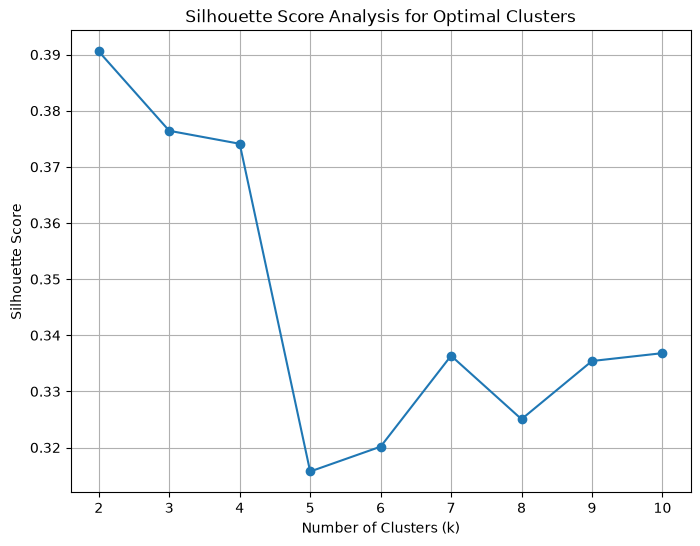

In [45]:
# Define the range of cluster numbers to evaluate
cluster_range = range(2, 11)
silhouette_scores = []

# Calculate silhouette score for each number of clusters
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(minmax_scaled_data)
    silhouette_avg = silhouette_score(minmax_scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette Scores
plt.figure(figsize=(8, 6))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title("Silhouette Score Analysis for Optimal Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

*2 cluster is the best*

### DBSCAN

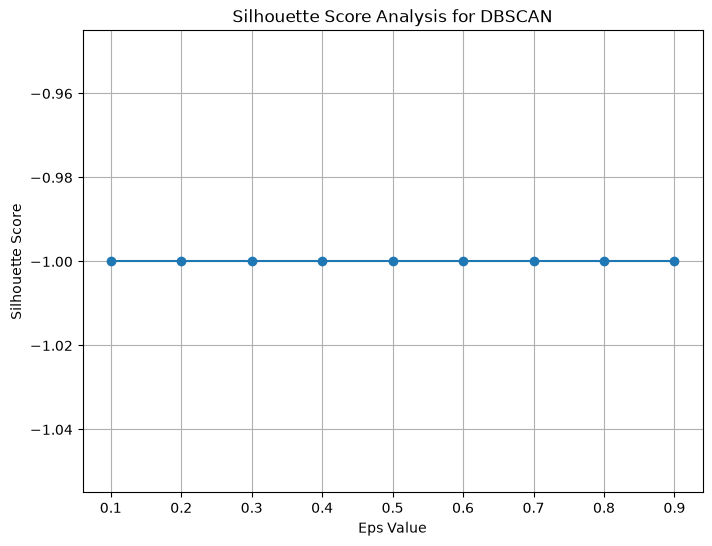

In [46]:
# Define range for eps values to test
eps_range = np.arange(0.1, 1.0, 0.1)    # Test eps from 0.1 to 1.0 in steps of 0.1
silhouette_scores = []

# Fixed min_samples
min_samples = 5

# Calculate silhouette score for each eps value
for eps in eps_range:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(minmax_scaled_data)
    
    # Calculate Silhouette Score only if valid clusters exist
    if len(set(dbscan_labels)) > 1 and -1 not in set(dbscan_labels):
        silhouette_avg = silhouette_score(minmax_scaled_data, dbscan_labels)
        silhouette_scores.append(silhouette_avg)
    else:
        silhouette_scores.append(-1)

# Plot Silhouette Scores
plt.figure(figsize=(8, 6))
plt.plot(eps_range, silhouette_scores, marker='o')
plt.title("Silhouette Score Analysis for DBSCAN")
plt.xlabel("Eps Value")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

Note: The negative Silhouette Score (-1) suggests that DBSCAN did not successfully discover meaningful clusters, indicating that the dataset may not be well-suited for density-based clustering. Therefore, a wider range of eps values will be tested to examine whether parameter tuning can improve the clustering performance.

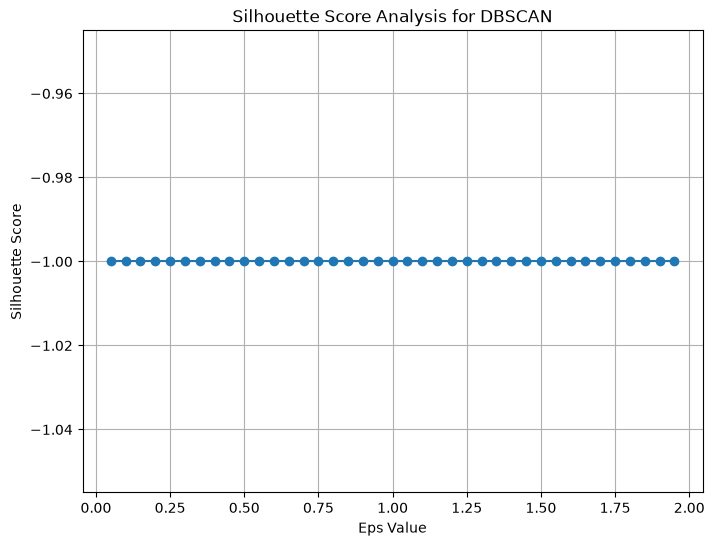

In [47]:
eps_range = np.arange(0.05, 2.0, 0.05)  # Test a wider range
silhouette_scores = []

# Fixed min_samples
min_samples = 5

# Calculate silhouette score for each eps value
for eps in eps_range:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(minmax_scaled_data)
    
    # Calculate Silhouette Score only if valid clusters exist
    if len(set(dbscan_labels)) > 1 and -1 not in set(dbscan_labels):
        silhouette_avg = silhouette_score(minmax_scaled_data, dbscan_labels)
        silhouette_scores.append(silhouette_avg)
    else:
        silhouette_scores.append(-1)

# Plot Silhouette Scores
plt.figure(figsize=(8, 6))
plt.plot(eps_range, silhouette_scores, marker='o')
plt.title("Silhouette Score Analysis for DBSCAN")
plt.xlabel("Eps Value")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

As changing the eps range did not produce any noticeable improvement, the distance distribution between samples will be examined to determine a more suitable eps value for the DBSCAN algorithm.

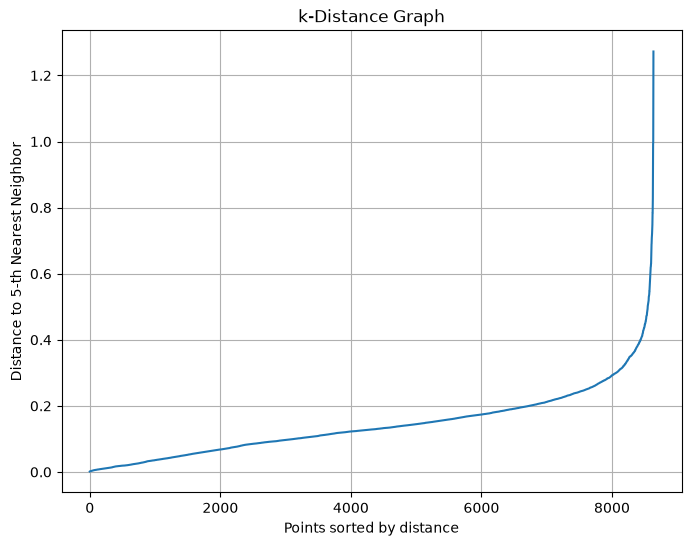

In [48]:
from sklearn.neighbors import NearestNeighbors

# Compute the k-distance graph
k = 5
nearest_neighbors = NearestNeighbors(n_neighbors=k)
neighbors = nearest_neighbors.fit(minmax_scaled_data)
distances, indices = neighbors.kneighbors(minmax_scaled_data)

# Sort and plot distances
distances = np.sort(distances[:, k-1])
plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.title("k-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {k}-th Nearest Neighbor")
plt.grid(True)
plt.show()

The Elbow Point in the distance distribution curve provides an estimation of a suitable eps value for DBSCAN. According to the plot, values between 0.3 and 0.5 appear to be reasonable candidates. Since the initial DBSCAN implementation with eps = 0.5 produced the most acceptable result, this parameter was considered the preferred choice.

The DBSCAN model did not show any improvement after further parameter tuning. The initial configuration remained the most effective setup among all tested experiments.

### GMM

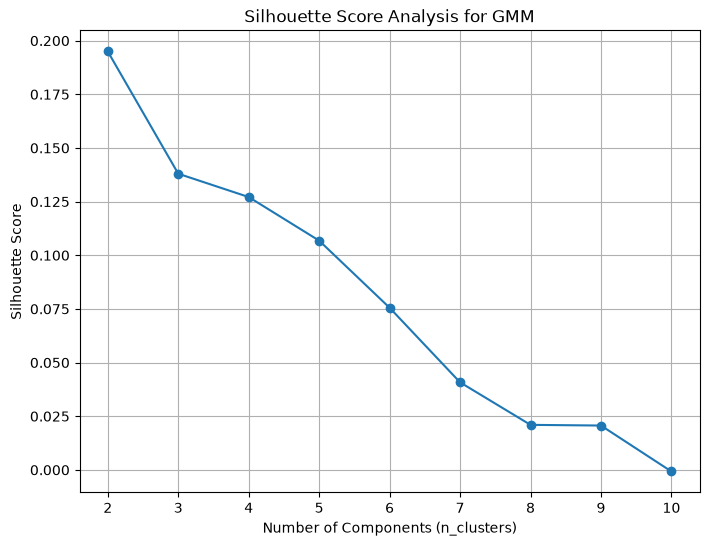

In [49]:
# Define the range for number of components to test
n_components_range = range(2, 11)
silhouette_scores = []

# Calculate silhouette score for each number of components
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm_labels = gmm.fit_predict(minmax_scaled_data)
    silhouette_avg = silhouette_score(minmax_scaled_data, gmm_labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette Scores
plt.figure(figsize=(8, 6))
plt.plot(n_components_range, silhouette_scores, marker='o')
plt.title("Silhouette Score Analysis for GMM")
plt.xlabel("Number of Components (n_clusters)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

The optimal configuration for GMM was obtained with two components, but the achieved performance was still lower than K-Means. Therefore, GMM was considered less effective for this dataset and was excluded from further analysis.

---

# Final Result

In [50]:
# K-Means parameter
n_clusters = 2

# Apply K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(minmax_scaled_data)

# Evaluate K-Means with Silhouette Score
kmeans_silhouette = silhouette_score(minmax_scaled_data, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_silhouette}")

K-Means Silhouette Score: 0.3905501972265014


The Silhouette Score increased from 0.38 in the initial experiment to 0.39 after optimization, indicating a slight improvement in clustering quality and better separation between the generated clusters.

In [51]:
# GMM parameter
n_components = 2

# Apply GMM
gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm_labels = gmm.fit_predict(minmax_scaled_data)

# Evaluate GMM with Silhouette Score
gmm_silhouette = silhouette_score(minmax_scaled_data, gmm_labels)
print(f"GMM Silhouette Score: {gmm_silhouette}")

GMM Silhouette Score: 0.1949518537785744


The Silhouette Score improved from 0.14 in the initial GMM experiment to 0.19 after optimization, showing a moderate enhancement in clustering performance. However, the overall quality of the generated clusters remained lower compared with the K-Means approach.

**So K-Mean gives us the best result among these three algorithms**

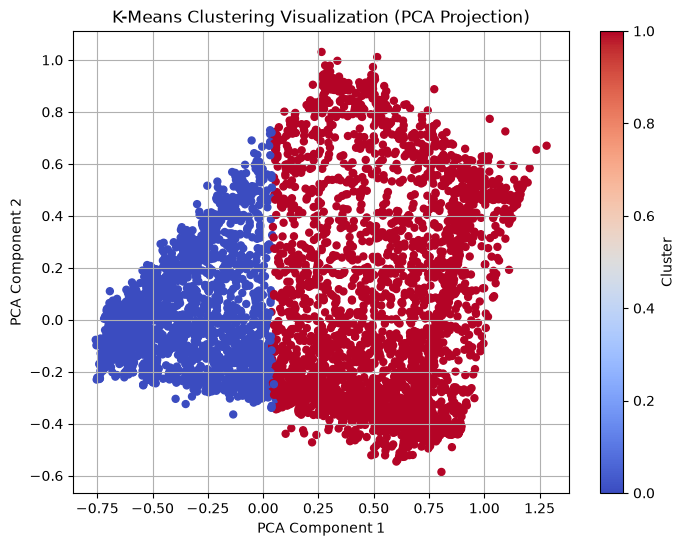

In [78]:
# Perform PCA to reduce data to 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(minmax_scaled_data)

# Add cluster labels to the dataset for visualization
kmeans_labels = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(minmax_scaled_data)

# Plot PCA results
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=kmeans_labels,
    cmap='coolwarm',
    s=25
)

plt.title("K-Means Clustering Visualization (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

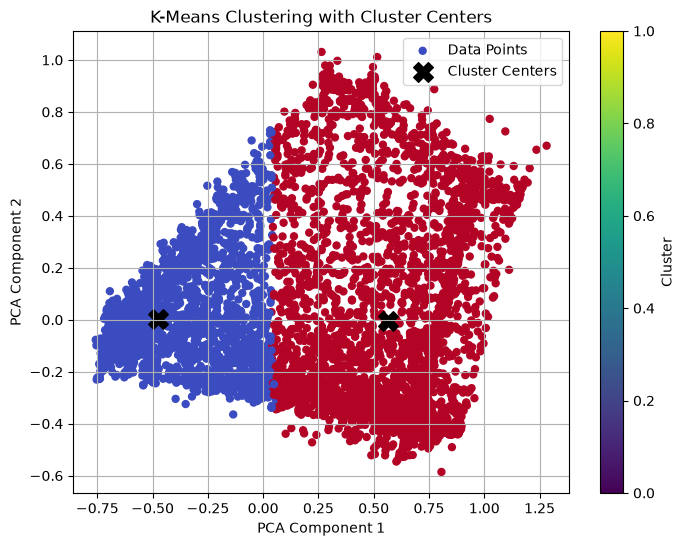

In [79]:
# Fit K-Means again to get cluster centers
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(minmax_scaled_data)

cluster_centers = pca.transform(kmeans.cluster_centers_)  # Transform centers to PCA space

# Scatter plot with cluster centers
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=kmeans_labels,
    cmap='coolwarm',
    s=25,
    label="Data Points"
)

plt.scatter(
    cluster_centers[:, 0],
    cluster_centers[:, 1],
    c='black',
    marker='X',
    s=200,
    label="Cluster Centers"
)

plt.title("K-Means Clustering with Cluster Centers")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(label="Cluster")
plt.legend()
plt.grid(True)
plt.show()

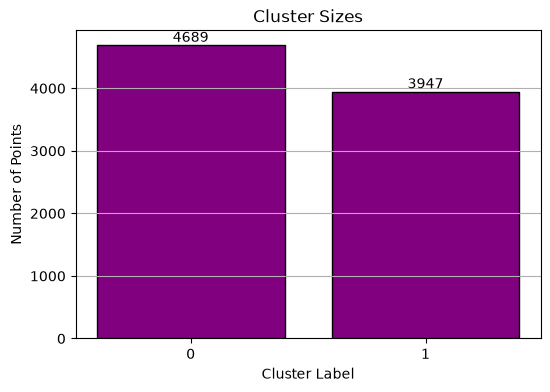

In [82]:
# Count data points in each cluster
cluster_counts = np.unique(kmeans_labels, return_counts=True)

# Bar plot
plt.figure(figsize=(6, 4))
bars = plt.bar(cluster_counts[0], cluster_counts[1], color='purple', edgecolor='black')

plt.title("Cluster Sizes")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Points")
plt.xticks(cluster_counts[0])

plt.bar_label(bars)

plt.grid(axis='y')
plt.show()

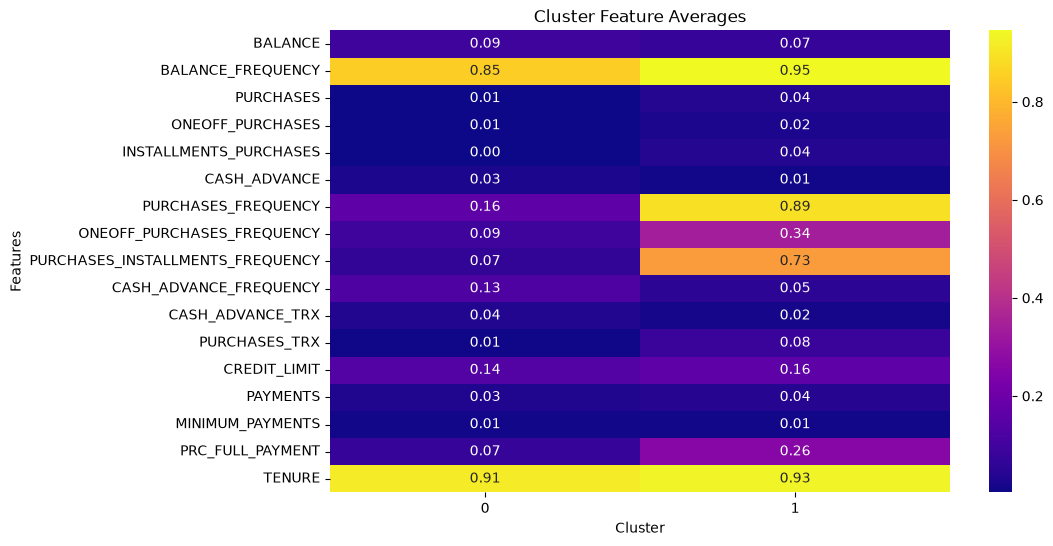

In [85]:
# Convert scaled data back to a DataFrame
scaled_df = pd.DataFrame(minmax_scaled_data, columns=cleaned_data_numeric.columns)
scaled_df['Cluster'] = kmeans_labels

# Calculate cluster-wise feature means
cluster_means = scaled_df.groupby('Cluster').mean()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means.T, cmap='plasma', annot=True, fmt=".2f")
plt.title("Cluster Feature Averages")
plt.xlabel("Cluster")
plt.ylabel("Features")
plt.show()

#### Any questions? => contact: shayanrokhva1999(at)gmail